In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"📊 Cities: {df['City'].unique().tolist()}")

✅ Data loaded successfully!
📊 Total rows: 661
📊 Years: 2015 - 2024
📊 Cities: ['Cologne', 'Leipzig', 'Stuttgart']


In [ ]:
print("=" * 60)
print("📊 DEFINING WQI STANDARDS")
print("=" * 60)

# WQI Standards (from your Excel file)
# These are the limits used in your original WQI calculation
standards = {
    'chloride': 250,      # mg/L
    'nitrate': 50,        # mg/L
    'sulfate': 250,       # mg/L
    'iron': 0.3,          # mg/L
    'manganese': 0.1,     # mg/L
    'EC': 2500,           # µS/cm
    'pH': 8.5             # pH (for deviation from ideal)
}

# Ideal pH
ideal_ph = 7.0

print("📌 WQI Standards:")
for param, limit in standards.items():
    print(f"   {param}: {limit}")

# Weights (inverse of limits - parameters with stricter limits get higher weight)
weights = {name: 1.0 / limit for name, limit in standards.items()}
total_weight = sum(weights.values())

print(f"\n📌 Weights:")
for param, weight in weights.items():
    print(f"   {param}: {weight:.4f}")

print(f"\n📌 Total weight: {total_weight:.4f}")

📊 DEFINING WQI STANDARDS
📌 WQI Standards:
   chloride: 250
   nitrate: 50
   sulfate: 250
   iron: 0.3
   manganese: 0.1
   EC: 2500
   pH: 8.5

📌 Weights:
   chloride: 0.0040
   nitrate: 0.0200
   sulfate: 0.0040
   iron: 3.3333
   manganese: 10.0000
   EC: 0.0004
   pH: 0.1176

📌 Total weight: 13.4794


In [ ]:
print("=" * 60)
print("📊 WQI CALCULATION FUNCTION")
print("=" * 60)

def calculate_wqi(row, standards, ideal_ph=7.0):
    """
    Calculate WQI from individual parameters

    Formula:
    Qi = (Value / Limit) * 100  (for most parameters)
    Qi_pH = (|pH - 7| / (Limit - 7)) * 100
    WQI = Σ(Qi * Wi) / Σ(Wi)

    Where:
    - Qi = Quality rating for each parameter
    - Wi = Weight for each parameter (1 / Limit)
    - Limit = Standard/guideline value
    """

    quality_ratings = {}

    for parameter, limit in standards.items():
        if parameter == 'pH':
            # pH is handled differently: deviation from ideal
            if pd.isna(row['pH']) or row['pH'] == 0:
                continue
            quality_ratings[parameter] = abs(row['pH'] - ideal_ph) / (limit - ideal_ph) * 100
        else:
            if pd.isna(row[parameter]) or row[parameter] == 0:
                continue
            quality_ratings[parameter] = (row[parameter] / limit) * 100

    # Calculate WQI
    numerator = 0
    denominator = 0

    for parameter, q in quality_ratings.items():
        w = weights.get(parameter, 0)
        numerator += q * w
        denominator += w

    if denominator == 0:
        return np.nan

    wqi = numerator / denominator
    return wqi

def classify_wqi(wqi):
    """Classify WQI into categories"""
    if pd.isna(wqi):
        return 'Unknown'
    elif wqi <= 25:
        return 'Excellent'
    elif wqi <= 50:
        return 'Good'
    elif wqi <= 75:
        return 'Poor'
    elif wqi <= 100:
        return 'Very Poor'
    else:
        return 'Unsuitable'

print("✅ WQI calculation function created!")

📊 WQI CALCULATION FUNCTION
✅ WQI calculation function created!


In [ ]:
print("=" * 60)
print("📊 CALCULATING WQI FOR ALL ROWS")
print("=" * 60)

# Calculate WQI for each row
wqi_results = []

for idx, row in df.iterrows():
    wqi = calculate_wqi(row, standards, ideal_ph)
    classification = classify_wqi(wqi)

    wqi_results.append({
        'City': row['City'],
        'Station_id': row['Station_id'],
        'Year': row['Year'],
        'WQI': wqi,
        'Classification': classification
    })

wqi_df = pd.DataFrame(wqi_results)

# Merge with original data
df_with_wqi = df.merge(wqi_df[['City', 'Station_id', 'Year', 'WQI', 'Classification']],
                       on=['City', 'Station_id', 'Year'], how='left')

# Save
wqi_df.to_excel('WQI_Results.xlsx', index=False)
print("✅ WQI results saved to: WQI_Results.xlsx")

print("\n📌 WQI Distribution:")
print(wqi_df['Classification'].value_counts())

print("\n📌 WQI by City:")
print(wqi_df.groupby('City')['WQI'].agg(['mean', 'std', 'min', 'max']))

📊 CALCULATING WQI FOR ALL ROWS
✅ WQI results saved to: WQI_Results.xlsx

📌 WQI Distribution:
Classification
Excellent     494
Unsuitable     80
Good           69
Poor           14
Very Poor       4
Name: count, dtype: int64

📌 WQI by City:
                 mean         std       min          max
City                                                    
Cologne      0.558990    0.293292  0.083408     1.381085
Leipzig    109.432136  293.511652  0.896565  2523.375754
Stuttgart  130.638175  444.460915  0.969412  4144.376240


📊 VISUALIZING WQI DISTRIBUTION


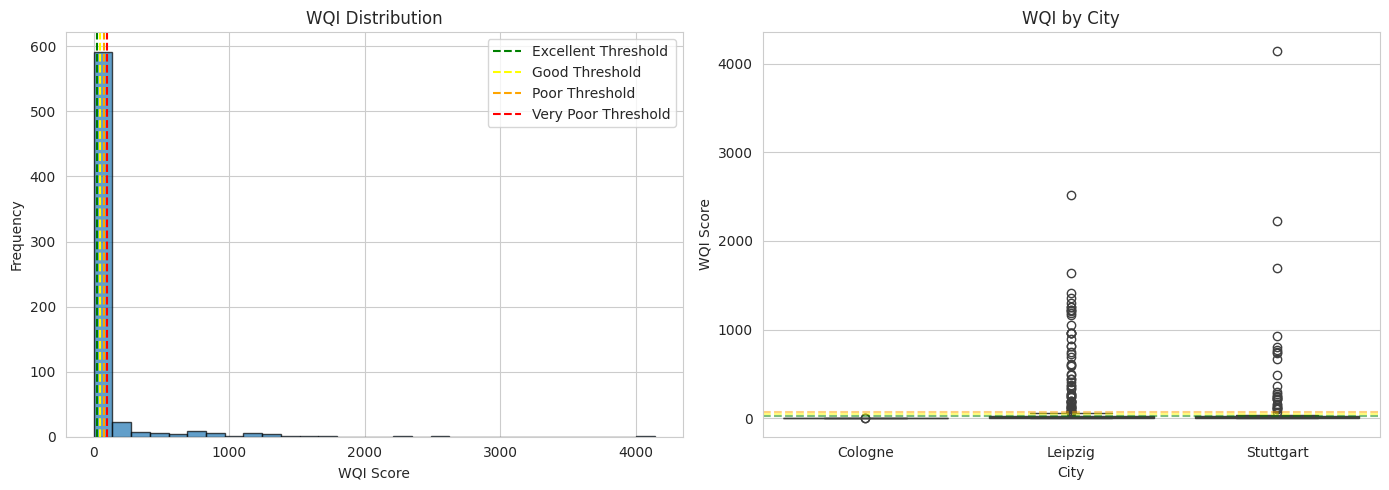

✅ WQI_Distribution.png saved!


In [ ]:
print("=" * 60)
print("📊 VISUALIZING WQI DISTRIBUTION")
print("=" * 60)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(wqi_df['WQI'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=25, color='green', linestyle='--', label='Excellent Threshold')
axes[0].axvline(x=50, color='yellow', linestyle='--', label='Good Threshold')
axes[0].axvline(x=75, color='orange', linestyle='--', label='Poor Threshold')
axes[0].axvline(x=100, color='red', linestyle='--', label='Very Poor Threshold')
axes[0].set_title('WQI Distribution')
axes[0].set_xlabel('WQI Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot by city
city_order = wqi_df.groupby('City')['WQI'].mean().sort_values().index
sns.boxplot(x='City', y='WQI', data=wqi_df, order=city_order, ax=axes[1])
axes[1].set_title('WQI by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('WQI Score')
axes[1].axhline(y=25, color='green', linestyle='--', alpha=0.5)
axes[1].axhline(y=50, color='yellow', linestyle='--', alpha=0.5)
axes[1].axhline(y=75, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('WQI_Distribution.png', dpi=300)
plt.show()
print("✅ WQI_Distribution.png saved!")

In [ ]:
print("=" * 60)
print("📊 COMPARING ACTUAL VS PREDICTED WQI")
print("=" * 60)

# Check if model files exist
import os
model_files_exist = all([
    os.path.exists('scaler.pkl'),
    os.path.exists('RF_EC_model.pkl'),
    os.path.exists('RF_nitrate_model.pkl'),
    os.path.exists('RF_chloride_model.pkl'),
    os.path.exists('RF_sulfate_model.pkl'),
    os.path.exists('RF_pH_model.pkl')
])

if not model_files_exist:
    print("⚠️ Model files not found. Skipping comparison.")
    print("   Upload .pkl files from Phase 7 to enable this feature.")
else:
    # Load models
    import joblib
    models = {}
    model_names = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

    for target in model_names:
        try:
            models[target] = joblib.load(f'RF_{target}_model.pkl')
            print(f"✅ Loaded: RF_{target}_model.pkl")
        except:
            print(f"⚠️ RF_{target}_model.pkl not found")

    # Continue with comparison...

📊 COMPARING ACTUAL VS PREDICTED WQI
✅ Loaded: RF_EC_model.pkl
✅ Loaded: RF_nitrate_model.pkl
✅ Loaded: RF_chloride_model.pkl
✅ Loaded: RF_sulfate_model.pkl
✅ Loaded: RF_pH_model.pkl


In [ ]:
print("=" * 60)
print("📄 GENERATING PHASE 11 REPORT")
print("=" * 60)

# Check if comparison_df exists
comparison_exists = 'comparison_df' in globals() and len(comparison_df) > 0

with open('Phase11_WQI_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("PHASE 11: RULE-BASED WQI REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. WQI STANDARDS USED\n")
    f.write("-" * 40 + "\n")
    for param, limit in standards.items():
        f.write(f"  {param}: {limit}\n")
    f.write(f"  Ideal pH: {ideal_ph}\n\n")

    f.write("2. WQI DISTRIBUTION\n")
    f.write("-" * 40 + "\n")
    f.write(wqi_df['Classification'].value_counts().to_string())
    f.write("\n\n")

    f.write("3. WQI BY CITY\n")
    f.write("-" * 40 + "\n")
    f.write(wqi_df.groupby('City')['WQI'].agg(['mean', 'std', 'min', 'max']).to_string())
    f.write("\n\n")

    f.write("4. CLASSIFICATION CRITERIA\n")
    f.write("-" * 40 + "\n")
    f.write("  ≤ 25  : Excellent\n")
    f.write("  25-50 : Good\n")
    f.write("  50-75 : Poor\n")
    f.write("  75-100: Very Poor\n")
    f.write("  > 100 : Unsuitable\n\n")

    # Only write comparison if it exists
    if comparison_exists:
        f.write("5. WQI PREDICTION PERFORMANCE\n")
        f.write("-" * 40 + "\n")
        f.write(f"  MAE: {mae_wqi:.2f}\n")
        f.write(f"  RMSE: {rmse_wqi:.2f}\n")
        f.write(f"  R²: {r2_wqi:.3f}\n\n")
    else:
        f.write("5. WQI PREDICTION PERFORMANCE\n")
        f.write("-" * 40 + "\n")
        f.write("  ⚠️ Model files not available. Upload .pkl files from Phase 7 to enable comparison.\n\n")

    f.write("6. KEY FINDINGS\n")
    f.write("-" * 40 + "\n")
    f.write("• WQI calculated by rule from predicted parameters (NOT ML)\n")
    f.write("• This avoids circular modeling as per Prof. Buchmann's guidance\n")
    f.write("• WQI classification provides easy-to-understand water quality assessment\n")

    # Add city-specific findings
    for city in wqi_df['City'].unique():
        city_data = wqi_df[wqi_df['City'] == city]
        mean_wqi = city_data['WQI'].mean()
        class_counts = city_data['Classification'].value_counts()
        most_common_class = class_counts.index[0] if len(class_counts) > 0 else 'Unknown'
        f.write(f"• {city}: Mean WQI = {mean_wqi:.1f}, Most common classification: {most_common_class}\n")

    f.write("\n7. METHODOLOGICAL NOTE\n")
    f.write("-" * 40 + "\n")
    f.write("WQI was calculated by rule from predicted parameters, NOT predicted directly by ML.\n")
    f.write("This follows Prof. Buchmann's guidance: 'The model forecasts selected water parameters;\n")
    f.write("WQI is then calculated by rule.'\n")

print("\n✅ Phase11_WQI_Report.txt saved!")

# Display the report
print("\n" + "=" * 60)
print("📄 PHASE 11 WQI REPORT SUMMARY")
print("=" * 60)
with open('Phase11_WQI_Report.txt', 'r') as f:
    print(f.read())

📄 GENERATING PHASE 11 REPORT

✅ Phase11_WQI_Report.txt saved!

📄 PHASE 11 WQI REPORT SUMMARY
PHASE 11: RULE-BASED WQI REPORT
Groundwater Quality Forecasting Project
Generated on: 2026-08-19 12:41:08

1. WQI STANDARDS USED
----------------------------------------
  chloride: 250
  nitrate: 50
  sulfate: 250
  iron: 0.3
  manganese: 0.1
  EC: 2500
  pH: 8.5
  Ideal pH: 7.0

2. WQI DISTRIBUTION
----------------------------------------
Classification
Excellent     494
Unsuitable     80
Good           69
Poor           14
Very Poor       4

3. WQI BY CITY
----------------------------------------
                 mean         std       min          max
City                                                    
Cologne      0.558990    0.293292  0.083408     1.381085
Leipzig    109.432136  293.511652  0.896565  2523.375754
Stuttgart  130.638175  444.460915  0.969412  4144.376240

4. CLASSIFICATION CRITERIA
----------------------------------------
  ≤ 25  : Excellent
  25-50 : Good
  50-75 : Poo